In [20]:
import re
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

import matplotlib.pyplot as plt

In [21]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [22]:
VOCAB_SIZE = 10000
MAX_LENGTH = 250
EMBEDDING_DIM = 128
LSTM_UNITS = 64
BATCH_SIZE = 64
EPOCHS = 10

In [23]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [24]:
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


In [25]:
print("First review:")
print(x_train[0])

First review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [26]:
print("First label:", y_train[0])

First label: 1


In [27]:
print("Length of first review:", len(x_train[0]))
print("Length of second review:", len(x_train[1]))
print("Length of third review:", len(x_train[2]))

Length of first review: 218
Length of second review: 189
Length of third review: 141


In [28]:
train_lengths = [len(review) for review in x_train]

print("Minimum review length:", min(train_lengths))
print("Maximum review length:", max(train_lengths))

Minimum review length: 11
Maximum review length: 2494


In [29]:
x_train = pad_sequences(
    x_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training data shape:", x_train.shape)

Training data shape: (25000, 250)


In [30]:
x_test = pad_sequences(
    x_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Testing data shape:", x_test.shape)

Testing data shape: (25000, 250)


In [31]:
print("First 20 values:")
print(x_train[0][:20])

print("\nLast 20 values:")
print(x_train[0][-20:])

First 20 values:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25]

Last 20 values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [32]:
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training labels shape: (25000,)
Testing labels shape: (25000,)


In [33]:
model = Sequential([
    
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),
    
    SpatialDropout1D(0.2),
    
    LSTM(LSTM_UNITS),
    
    Dropout(0.4),
    
    Dense(
        1,
        activation="sigmoid"
    )
])

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [36]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [37]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

In [38]:
history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7646 - loss: 0.4876 - val_accuracy: 0.8476 - val_loss: 0.3830 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8794 - loss: 0.3076 - val_accuracy: 0.8488 - val_loss: 0.3730 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9129 - loss: 0.2320 - val_accuracy: 0.8604 - val_loss: 0.3656 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9297 - loss: 0.1940 - val_accuracy: 0.8564 - val_loss: 0.3798 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9603 - loss: 0.1165 - val_accuracy: 0.8540 - val_loss: 0.4277 - learning_rate: 5.0000e-04


In [39]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8484 - loss: 0.3913
Test Loss: 0.39128366112709045
Test Accuracy: 0.8483999967575073


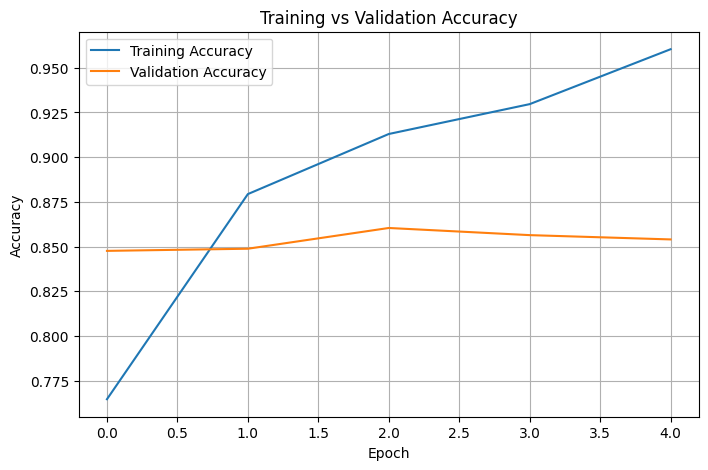

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)
plt.show()

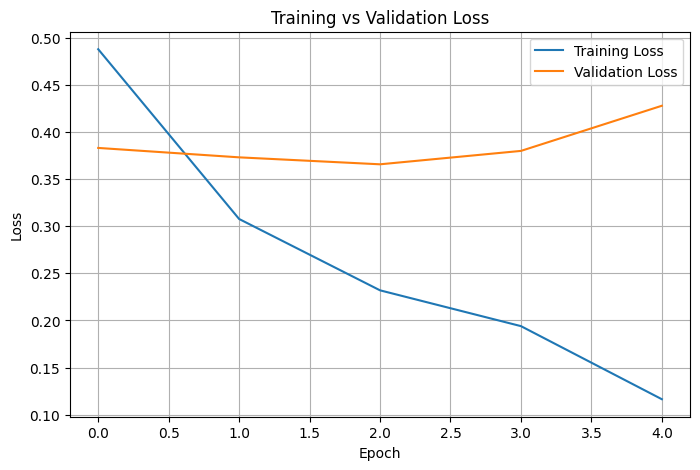

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.show()

In [42]:
word_index = imdb.get_word_index()

print("Vocabulary size:", len(word_index))

Vocabulary size: 88584


In [43]:
def encode_review(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        "",
        text
    )
    
    # Split text into individual words
    words = text.split()
    
    # Store encoded word IDs
    encoded = []
    
    for word in words:
        
        if word in word_index:
            encoded.append(word_index[word] + 3)
        
        else:
            # Unknown word token
            encoded.append(2)
    
    # IMPORTANT:
    # Use post-padding to match the training data
    encoded = pad_sequences(
        [encoded],
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )
    
    return encoded

In [44]:
review = "This movie was absolutely fantastic. I really enjoyed it."

encoded_review = encode_review(review)

print("Encoded review:")
print(encoded_review)

print("\nShape:")
print(encoded_review.shape)

Encoded review:
[[ 14  20  16 427 777  13  66 510  12   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0 

In [45]:
print("First 20 values:")
print(encoded_review[0][:20])

print("\nLast 20 values:")
print(encoded_review[0][-20:])

First 20 values:
[ 14  20  16 427 777  13  66 510  12   0   0   0   0   0   0   0   0   0
   0   0]

Last 20 values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
# Test the loaded model with a new review
review = "This movie was absolutely fantastic. I really enjoyed it."

encoded_review = encode_review(review)

prediction = model.predict(
    encoded_review,
    verbose=0
)

print("Prediction probability:", prediction[0][0])

Prediction probability: 0.77585644


In [47]:
if prediction[0][0] >= 0.5:
    print("Sentiment: Positive 😊")
else:
    print("Sentiment: Negative 😞")

Sentiment: Positive 😊


In [ ]:
# Test the loaded model with a new review negative review
review = "This movie was extremely boring and disappointing. I hated it."

encoded_review = encode_review(review)

prediction = model.predict(
    encoded_review,
    verbose=0
)

print("Prediction probability:", prediction[0][0])

Prediction probability: 0.01384734


In [50]:
if prediction[0][0] >= 0.5:
    print("Sentiment: Positive 😊")
else:
    print("Sentiment: Negative 😞")

Sentiment: Negative 😞


In [51]:
def predict_sentiment(review):
    
    encoded_review = encode_review(review)
    
    prediction = model.predict(
        encoded_review,
        verbose=0
    )[0][0]
    
    if prediction >= 0.5:
        sentiment = "Positive 😊"
    else:
        sentiment = "Negative 😞"
    
    return sentiment, prediction

In [52]:
reviews = [
    "This movie was absolutely amazing and wonderful.",
    "The movie was boring and a complete waste of time.",
    "I loved the acting and the story was fantastic.",
    "Terrible movie. I hated every minute of it."
]

for review in reviews:
    
    sentiment, probability = predict_sentiment(review)
    
    print("Review:", review)
    print("Prediction:", sentiment)
    print("Probability:", round(probability, 4))
    print("-" * 70)

Review: This movie was absolutely amazing and wonderful.
Prediction: Positive 😊
Probability: 0.9694
----------------------------------------------------------------------
Review: The movie was boring and a complete waste of time.
Prediction: Negative 😞
Probability: 0.0147
----------------------------------------------------------------------
Review: I loved the acting and the story was fantastic.
Prediction: Positive 😊
Probability: 0.8774
----------------------------------------------------------------------
Review: Terrible movie. I hated every minute of it.
Prediction: Negative 😞
Probability: 0.0761
----------------------------------------------------------------------


In [53]:
review = "The movie was not good."

sentiment, probability = predict_sentiment(review)

print("Review:", review)
print("Prediction:", sentiment)
print("Probability:", round(probability, 4))

Review: The movie was not good.
Prediction: Positive 😊
Probability: 0.5966


In [54]:
review = "Although the movie started slowly, the ending was excellent."

sentiment, probability = predict_sentiment(review)

print("Review:", review)
print("Prediction:", sentiment)
print("Probability:", round(probability, 4))

Review: Although the movie started slowly, the ending was excellent.
Prediction: Positive 😊
Probability: 0.9065


In [55]:
model.save(
    "imdb_lstm_sentiment_model.keras"
)

print("Model saved successfully!")

Model saved successfully!


In [56]:
loaded_model = tf.keras.models.load_model(
    "imdb_lstm_sentiment_model.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [57]:
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,421 (15.21 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,658,948 (10.14 MB)

In [58]:
review = "The movie was fantastic and I really enjoyed it."

encoded_review = encode_review(review)

prediction = loaded_model.predict(
    encoded_review,
    verbose=0
)[0][0]

print("Probability:", prediction)

if prediction >= 0.5:
    print("Sentiment: Positive 😊")
else:
    print("Sentiment: Negative 😞")

Probability: 0.8842705
Sentiment: Positive 😊
